# Torch-Rechub Tutorial：Multi-Task
- 场景：精排（多任务学习）

- 模型：ESMM

- 数据：Ali-CCP数据集

- 学习目标

  - 学会使用torch-rechub训练一个ESMM模型

- 更多学习材料：

  - 多任务模型介绍：https://datawhalechina.github.io/fun-rec/#/ch02/ch2.2/ch2.2.5/2.2.5.0

  - Ali-CCP数据集官网：https://tianchi.aliyun.com/dataset/dataDetail?dataId=408

- 注意事项：本教程模型部分的超参数并未调优，欢迎小伙伴在学完教程后参与调参和在全量数据上进行测评工作

# 理论学习：


## 1.3 多任务学习实践：ESMM（Entire Space Multi-Task Model）

### 1.3.1 前言

在推荐系统中，一个非常典型的任务链是：

> **CTR（Click Through Rate） → CVR（Conversion Rate）**

例如在电商推荐场景：

用户看到商品 → 点击商品 → 最终购买商品

对应三个概率：

- **曝光 → 点击：CTR**
- **点击 → 转化：CVR**
- **曝光 → 转化：CTCVR**

但在真实训练数据中，我们会遇到一个非常关键的问题：

> **CVR 只在点击样本上有标签。**

也就是说：

- 未点击样本：不知道是否会转化
- 只有点击样本：才可能有购买标签

这导致一个经典问题：

### Sample Selection Bias（样本选择偏差）

CVR模型训练的数据分布：

$$
p(x \mid click=1)
$$

而线上预测时面对的是：

$$
p(x)
$$

训练分布与真实分布不一致，从而导致 **CVR预测偏差**。

同时还存在第二个问题：

### Data Sparsity（数据稀疏）

转化行为远少于点击行为：

```
曝光  >> 点击  >> 转化
```

如果直接训练 CVR：

- 正样本极少
- 模型难以学习稳定表示

因此工业界提出了一个非常经典的模型：

> **ESMM（Entire Space Multi-Task Model）**

核心思想是：

> **在整个曝光空间上联合学习 CTR 与 CTCVR，从而间接得到 CVR。**

------

## 1.3.2 ESMM 理论介绍

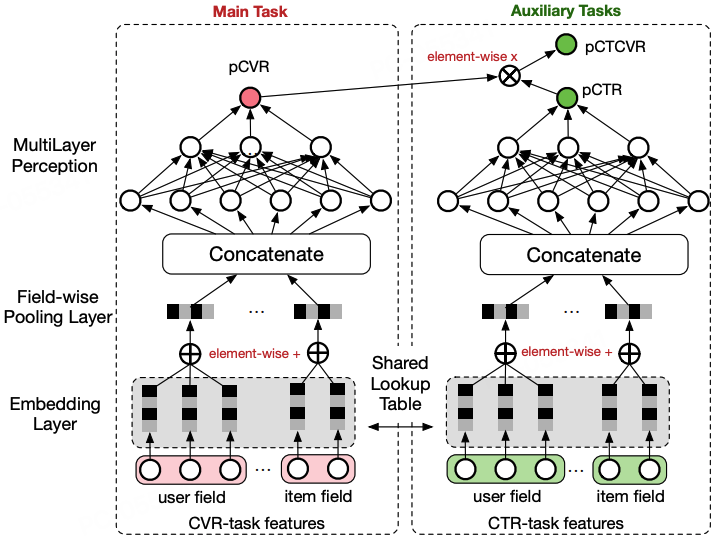


$$
\text{ESMM Framework}
$$

ESMM 的核心思想可以用一个非常简单的概率关系表示：

$$
P(\text{conversion}) =
P(\text{click}) \times
P(\text{conversion} \mid \text{click})
$$

即：

$$
CTCVR = CTR \times CVR
$$

ESMM 正是利用这个关系构建联合训练。

------

## 1.3.3 从直接 CVR 预测到 ESMM 的思路变化

传统方法通常直接训练：

$$
\hat{y}*{CVR} = f*{CVR}(x)
$$

但由于训练数据只来自：

$$
x \sim p(x|click=1)
$$

导致两个问题：

- 训练分布偏移
- 样本极度稀疏

ESMM 的关键改动是：

> **不直接训练 CVR，而是通过 CTR 与 CTCVR 间接建模。**

具体来说：

模型预测：

- CTR
- CTCVR

然后通过概率关系推导：

$$
CVR = \frac{CTCVR}{CTR}
$$

但在训练过程中并不会显式做这个除法，而是通过 **乘法关系进行约束学习**。

------

## 1.3.4 ESMM 的核心结构

ESMM 包含两个任务：

- **CTR任务**
- **CTCVR任务**

两个任务：

- 共享 **Embedding**
- 共享 **特征空间**
- 在 **整个曝光空间训练**

但输出不同。

模型结构如下：

```
           输入特征 x
                │
        Shared Embedding Layer
                │
        Field-wise Pooling
                │
           MLP 表示层
            /      \
        CTR Tower   CVR Tower
            │          │
         pCTR        pCVR
             \        /
             element-wise ×
                 │
              pCTCVR
```

也就是说：

$$
pCTCVR = pCTR \times pCVR
$$

------

## 1.3.5 ESMM 的数学表达

设：

- 输入特征：

$$
x
$$

- CTR概率：

$$
p_{ctr} = P(click \mid x)
$$

- CVR概率：

$$
p_{cvr} = P(conversion \mid click, x)
$$

根据链式法则：

$$
P(conversion \mid x) = P(click \mid x) \cdot P(conversion \mid click, x)
$$

即：

$$
p_{ctcvr} = p_{ctr} \times p_{cvr}
$$

模型输出为：

$$
\hat{p}_{ctr} = f_{ctr}(x),\quad \hat{p}_{cvr} = f_{cvr}(x)
$$

于是：

$$
\hat{p}_{ctcvr} = \hat{p}_{ctr} \cdot \hat{p}_{cvr}
$$

---

### 1.3.6 损失函数设计

ESMM 同时优化两个任务的损失。

#### CTR Loss（在整个曝光空间训练）

$$
\mathcal{L}_{CTR} = -y_{click}\log(\hat{p}_{ctr}) - (1-y_{click})\log(1-\hat{p}_{ctr})
$$

#### CTCVR Loss（标签为“点击且转化”）

定义：

$$
y_{ctcvr} =
\begin{cases}
1 & \text{if } click=1 \text{ and } conversion=1,\\
0 & \text{otherwise}
\end{cases}
$$

CTCVR 损失为：

$$
\mathcal{L}_{CTCVR} = -y_{ctcvr}\log(\hat{p}_{ctcvr}) - (1-y_{ctcvr})\log(1-\hat{p}_{ctcvr})
$$

#### 总损失

$$
\mathcal{L} = \mathcal{L}_{CTR} + \mathcal{L}_{CTCVR}
$$

---

### 1.3.7 为什么 ESMM 可以缓解样本选择偏差

关键在于：

> 所有任务都在整个曝光空间训练。

传统 CVR 训练只用点击样本（\(x\sim p(x\mid click)\)），而 ESMM 在训练时使用全部曝光样本（\(x\sim p(x)\)），因此训练分布更接近线上真实分布，从而缓解样本选择偏差并缓解数据稀疏问题。

---

### 1.3.8 梯度传播机制

由于：

$$
\hat{p}_{ctcvr} = \hat{p}_{ctr} \cdot \hat{p}_{cvr}
$$

CTCVR 损失对 CVR 的梯度为：

$$
\frac{\partial L}{\partial \hat{p}_{cvr}} = \frac{\partial L}{\partial \hat{p}_{ctcvr}} \cdot \hat{p}_{ctr}
$$

这意味着 CTR 的预测会影响 CVR 的学习强度，CTR 在某种程度上对 CVR 提供“门控”信号。

---

### 1.3.9 表示学习角度的理解

ESMM 隐式建模的是联合概率 \(P(click, conversion \mid x)\)，通过共享表示约束 CTR 与 CVR，使两者互相受益，缓解稀疏与偏差问题。

---

### 1.3.10 直观理解

业务流程：曝光 → 点击 → 购买

- CTR：预测是否点击  
- CVR：在点击条件下是否转化  
- CTCVR：从曝光直接到转化

ESMM 的结构与业务路径一致，因此更符合真实信号的分布。

---

### 1.3.11 本阶段总结

ESMM 通过联合建模 CTR 与 CTCVR，并利用概率关系：

$$
CTCVR = CTR \times CVR
$$

实现了：

- 缓解样本选择偏差（使用整个曝光空间训练）  
- 缓解数据稀疏（CTR 提供额外监督）  
- 更稳定的 CVR 学习与更好的转化预测效果

In [1]:
#使用pandas加载数据
import pandas as pd
data_path = '../../examples/ranking/data/ali-ccp' #数据存放文件夹
df_train = pd.read_csv(data_path + '/ali_ccp_train_sample.csv') #加载训练集
df_val = pd.read_csv(data_path + '/ali_ccp_val_sample.csv') #加载验证集
df_test = pd.read_csv(data_path + '/ali_ccp_test_sample.csv') #加载测试集
print("train : val : test = %d %d %d" % (len(df_train), len(df_val), len(df_test)))
#查看数据，其中'click'、'purchase'为标签列，'D'开头为dense特征列，其余为sparse特征，各特征列的含义参考官网描述
print(df_train.head(5)) 

train : val : test = 100 50 50
   click  purchase  101  121  122  124  125  126  127  128  ...  127_14  \
0      0         0    1    1    1    1    1    0    1    1  ...       1   
1      0         0    1    1    1    1    1    0    1    1  ...       1   
2      1         1    1    1    1    1    1    0    1    1  ...       1   
3      0         0    1    1    1    1    1    0    1    1  ...       1   
4      0         0    1    1    1    1    1    0    1    1  ...       1   

   150_14  D109_14  D110_14  D127_14  D150_14     D508   D509    D702     D853  
0       1   0.4734    0.562   0.0856   0.1902  0.07556  0.000  0.0000  0.00000  
1       1   0.4734    0.562   0.0856   0.1902  0.00000  0.000  0.0000  0.00000  
2       1   0.4734    0.562   0.0856   0.1902  0.56050  0.256  0.4626  0.34400  
3       1   0.4734    0.562   0.0856   0.1902  0.26150  0.000  0.0000  0.12213  
4       1   0.4734    0.562   0.0856   0.1902  0.35910  0.000  0.0000  0.00000  

[5 rows x 33 columns]


### 使用torch-rechub训练ESMM模型

#### 数据预处理
在数据预处理过程通常需要:
- 对稀疏分类特征进行Lable Encode
- 对于数值特征进行分桶或者归一化

由于本教程中的采样数据以及全量数据已经进行预处理，因此加载数据集可以直接使用。

本次的多任务模型的任务是预测点击和购买标签，是推荐系统中典型的CTR和CVR预测任务。

In [2]:
train_idx, val_idx = df_train.shape[0], df_train.shape[0] + df_val.shape[0]  # 计算训练集和验证集在拼接后 data 中的结束索引
data = pd.concat([df_train, df_val, df_test], axis=0)  # 按行拼接 train/val/test，得到完整数据集
# task 1 (as cvr): main task, purchase prediction（主任务：购买预测）
# task 2 (as ctr): auxiliary task, click prediction（辅助任务：点击预测）
data.rename(columns={'purchase': 'cvr_label', 'click': 'ctr_label'}, inplace=True)  # 重命名标签列，便于后续统一处理
data["ctcvr_label"] = data['cvr_label'] * data['ctr_label']  # 生成联合标签（点击且购买），常用于联合任务或作为条件概率的训练目标

#### 定义模型
定义一个模型需要指定模型结构参数,需要哪些参数可查看对应模型的定义部分。 
对于ESMM而言，主要参数如下：

- user_features指用户侧的特征，只能传入sparse类型（论文中需要分别对user和item侧的特征进行sum_pooling操作）
- item_features指用item侧的特征，只能传入sparse类型
- cvr_params指定CVR Tower中MLP层的参数
- ctr_params指定CTR Tower中MLP层的参数

In [6]:
from torch_rechub.models.multi_task import ESMM
from torch_rechub.basic.features import DenseFeature, SparseFeature

col_names = data.columns.values.tolist()
dense_cols = ['D109_14', 'D110_14', 'D127_14', 'D150_14', 'D508', 'D509', 'D702', 'D853']  # 数值（dense）特征列表
# sparse_cols：除去 dense 列和标签列后的其余列，视为稀疏（分类）特征
sparse_cols = [col for col in col_names if col not in dense_cols and col not in ['cvr_label', 'ctr_label', 'ctcvr_label']]
print("sparse cols:%d dense cols:%d" % (len(sparse_cols), len(dense_cols)))

label_cols = ['cvr_label', 'ctr_label', "ctcvr_label"]  # 三个标签列，顺序需固定（CVR, CTR, CTCVR）
used_cols = sparse_cols  # ESMM 原始论文仅使用稀疏特征作为输入
# item_cols：假设的 item 特征列索引（根据数据含义自行调整）
item_cols = ['129', '205', '206', '207', '210', '216']
# user_cols：将剩余稀疏特征视为用户侧特征
user_cols = [col for col in used_cols if col not in item_cols]

# 为用户侧和物品侧的稀疏特征创建 SparseFeature，embedding 维度设为 16
user_features = [SparseFeature(col, int(data[col].max()) + 1, embed_dim=16) for col in user_cols]
item_features = [SparseFeature(col, int(data[col].max()) + 1, embed_dim=16) for col in item_cols]

# 创建 ESMM 模型
# cvr_params: CVR 分支中 MLP 的维度配置；ctr_params: CTR 分支中 MLP 的维度配置
model = ESMM(user_features, item_features, cvr_params={"dims": [16, 8]}, ctr_params={"dims": [16, 8]})

sparse cols:23 dense cols:8


#### 构建dataloader

构建dataloader通常由
1. 构建输入字典（字典的键为定义模型时采用的特征名，值为对应特征的数据）
2. 通过字典构建相应的dataset和dataloader

In [7]:
from torch_rechub.utils.data import DataGenerator

x_train, y_train = {name: data[name].values[:train_idx] for name in used_cols}, data[label_cols].values[:train_idx]
x_val, y_val = {name: data[name].values[train_idx:val_idx] for name in used_cols}, data[label_cols].values[train_idx:val_idx]
x_test, y_test = {name: data[name].values[val_idx:] for name in used_cols}, data[label_cols].values[val_idx:]
dg = DataGenerator(x_train, y_train)
train_dataloader, val_dataloader, test_dataloader = dg.generate_dataloader(x_val=x_val, y_val=y_val, 
                                      x_test=x_test, y_test=y_test, batch_size=1024)

#### 训练模型及测试

- 训练模型通过相应的trainer进行，对于多任务的MTLTrainer需要设置任务的类型、优化器的超参数和优化策略等。

- 完成模型训练后对测试集进行测试


In [8]:
import torch
import os
from torch_rechub.trainers import MTLTrainer
# 选择设备：有可用 GPU 则用 cuda，否则用 cpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# 超参数设置
learning_rate = 1e-3  # 学习率
epoch = 1  # 训练轮数，示例中设为 1（真实训练可改为 10 或更大）
weight_decay = 1e-5  # 权重衰减（L2 正则化）

# 模型保存目录，若不存在则创建
save_dir = '../examples/ranking/data/ali-ccp/saved'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 指定每个任务的类型：CTR 与 CVR 均为二分类任务，第三个为联合标签的分类
task_types = ["classification", "classification", "classification"]

# 创建多任务训练器
# - model: 前面定义的 ESMM / MMOE 模型实例
# - task_types: 每个输出的任务类型列表
# - optimizer_params: 优化器参数（lr, weight_decay 等）
# - n_epoch: 训练轮数
# - earlystop_patience: 验证集早停阈值
# - device: 训练设备
# - model_path: 模型保存路径
mtl_trainer = MTLTrainer(model, task_types=task_types, 
              optimizer_params={"lr": learning_rate, "weight_decay": weight_decay}, 
              n_epoch=epoch, earlystop_patience=1, device=device, model_path=save_dir)
# 开始训练（传入训练与验证 dataloader）
mtl_trainer.fit(train_dataloader, val_dataloader)
# 在测试集上评估并打印 AUC（或 Trainer 返回的评估指标）
auc = mtl_trainer.evaluate(mtl_trainer.model, test_dataloader)
print(f'test auc: {auc}')

train: 100%|██████████| 1/1 [00:00<00:00,  2.03it/s]


train loss:  {'task_0:': np.float64(0.7875202894210815), 'task_1:': np.float64(0.7225522994995117), 'task_2:': np.float64(0.33220338821411133)}


validation: 100%|██████████| 1/1 [00:00<00:00, 138.09it/s]


epoch: 0 validation scores:  [0.326530612244898, 0.5319148936170213, 0.26530612244897955]


validation: 100%|██████████| 1/1 [00:00<00:00, 140.36it/s]

test auc: [0.18367346938775508, 0.36458333333333337, 0.1428571428571429]


# 附录：
## Ali-CCP数据集介绍
- [原始数据](https://tianchi.aliyun.com/dataset/dataDetail?dataId=408)：原始数据采集自手机淘宝移动客户端的推荐系统日志，一共有23个sparse特征，8个dense特征，包含“点击”、“购买”两个标签，各特征列的含义参考学习材料中的Ali-CCP数据集官网上的详细描述

- [全量数据](https://aistudio.baidu.com/datasetdetail/281072)：我们已经完成对原始数据集的处理，包括对sparse特征进行Lable Encode，dense特征采用归一化处理等。预处理脚本见torch-rechub/examples/ranking/data/ali-ccp/preprocess_ali_ccp.py

- [采样数据](https://github.com/datawhalechina/torch-rechub/tree/main/examples/ranking/data/ali-ccp)：从全量数据集采样的小数据集，供大家调试代码和学习使用，因此本次教程使用采样数据